# House Price Prediction - Final Project

## Day 21: Problem Statement & Initial Exploration

## Problem Statement
Predict house prices based on regional/area-level features (average income,
house age, number of rooms/bedrooms, and population) to help estimate fair
market value. This is a regression problem, evaluated using R² and RMSE.

## Dataset
Source: Kaggle - USA_Housing.csv (aariyan101)
5,000 rows, 7 columns (6 numeric features + 1 text column to be dropped)
No missing values.

Target variable: Price (range: ~$15,938 to ~$2,469,066, mean ~$1,232,073)


In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("USA_Housing.csv")   # match exact uploaded filename

Saving USA_Housing.csv to USA_Housing.csv


In [2]:
print(df.shape)
df.head()
df.info()
print(df.isnull().sum())
df.describe()

(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


## Day 22: Data Cleaning & EDA




In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Drop Address — not usable as a raw feature
df = df.drop(columns=["Address"])

# Double-check for duplicates (good habit even when you don't expect any)
print("Duplicates:", df.duplicated().sum())

# Verify final structure
df.info()

Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


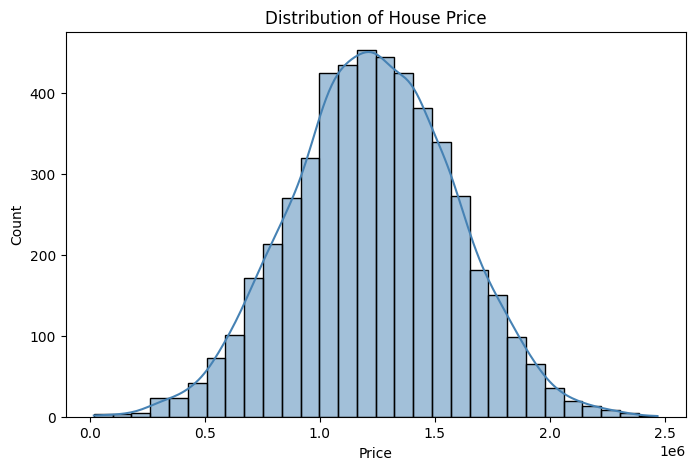

Skewness of Price: -0.002718064933559366


In [5]:
# Distribution of the target variable — most important check
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, bins=30, color="steelblue")
plt.title("Distribution of House Price")
plt.show()

print("Skewness of Price:", df["Price"].skew())

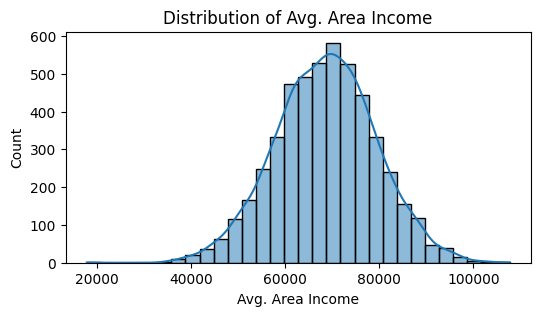

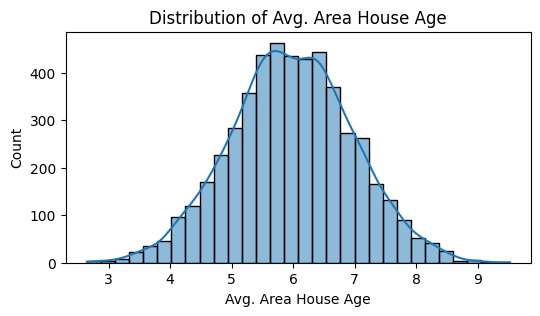

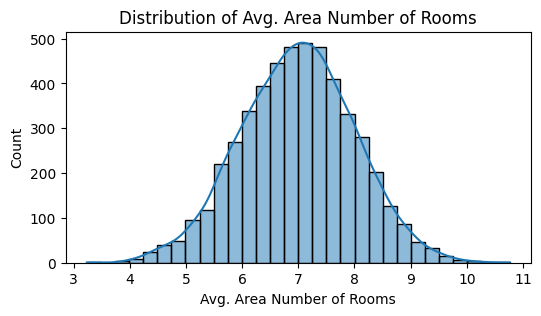

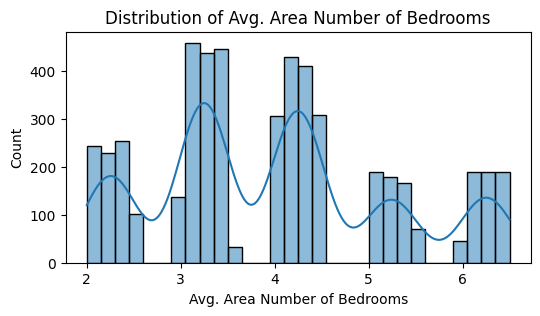

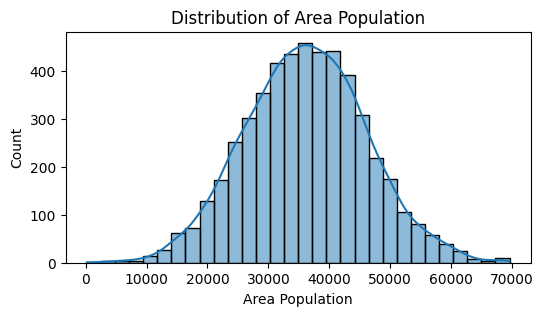

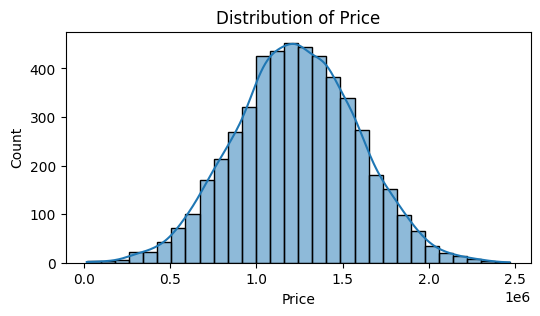

In [6]:
# Repeat for each numeric feature
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

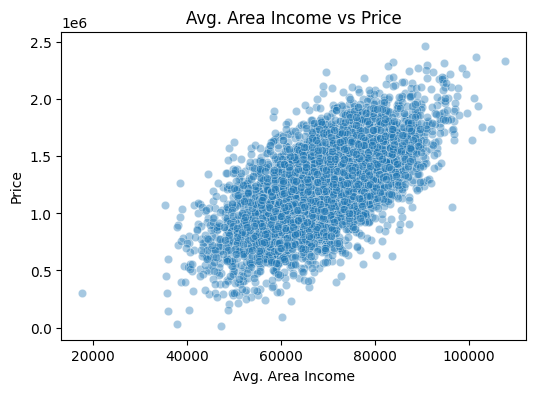

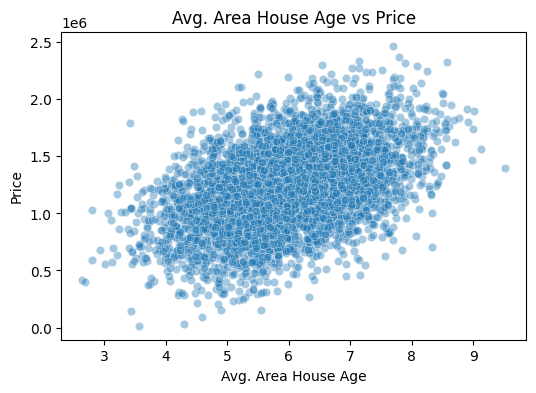

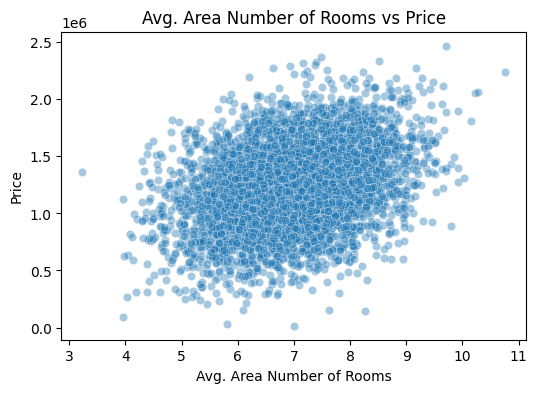

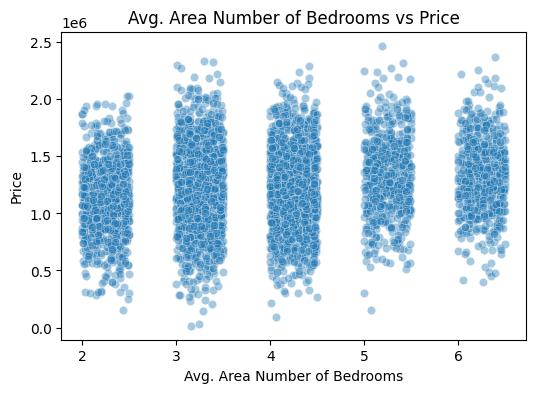

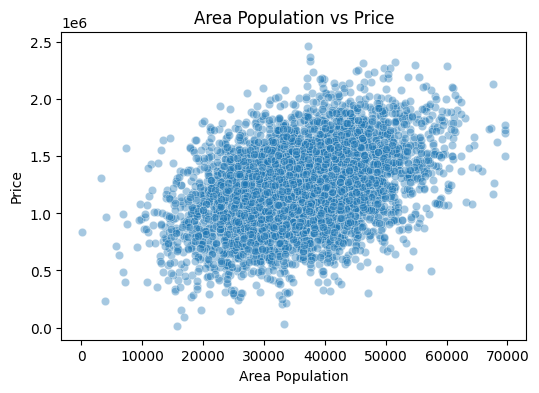

In [7]:
features = df.drop(columns=["Price"]).columns

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["Price"], alpha=0.4)
    plt.title(f"{col} vs Price")
    plt.show()

In [8]:
print(df.corr()["Price"].sort_values(ascending=False))

Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64


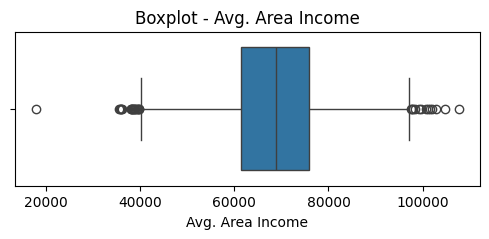

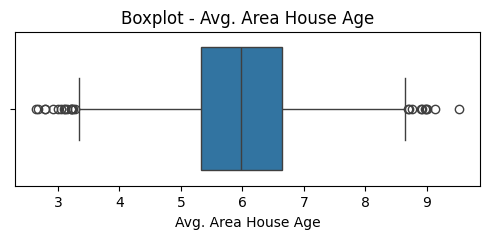

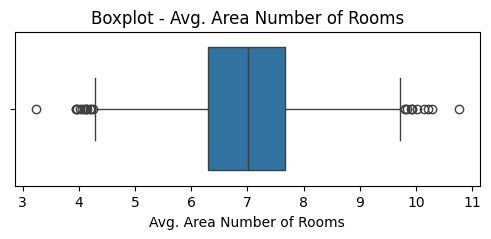

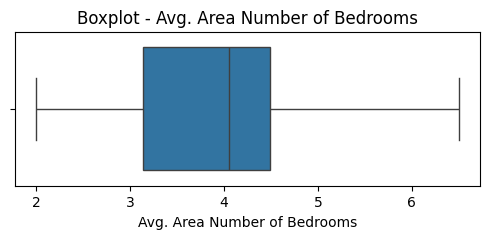

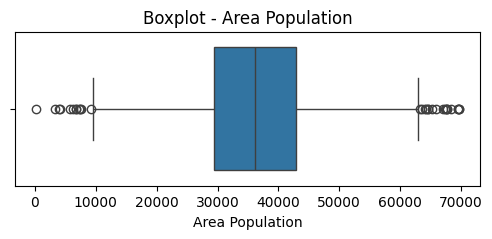

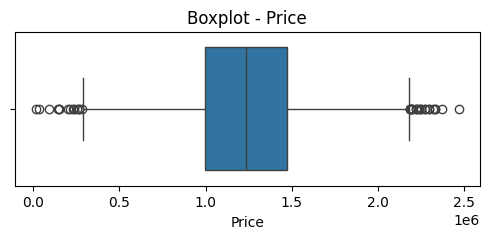

In [9]:
# Visual check
for col in df.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

In [10]:
# Numeric/statistical check using IQR (Interquartile Range) — more rigorous than "eyeballing" a boxplot
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

for col in df.columns:
    outliers, lower, upper = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (valid range: {lower:.2f} to {upper:.2f})")

Avg. Area Income: 32 outliers (valid range: 40026.40 to 97237.50)
Avg. Area House Age: 25 outliers (valid range: 3.33 to 8.64)
Avg. Area Number of Rooms: 24 outliers (valid range: 4.25 to 9.72)
Avg. Area Number of Bedrooms: 0 outliers (valid range: 1.11 to 6.52)
Area Population: 30 outliers (valid range: 9217.89 to 63047.33)
Price: 35 outliers (valid range: 287127.53 to 2181659.81)


## Day 23: Model Building & Evaluation





In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [12]:
X = df.drop(columns=["Price"])
y = df["Price"]

print(X.columns.tolist())
print(X.shape, y.shape)

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
(5000, 5) (5000,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4000, 5)
Test size: (1000, 5)


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  80,879.10
MSE:  10,089,009,300.89
RMSE: 100,444.06
R²:   0.9180


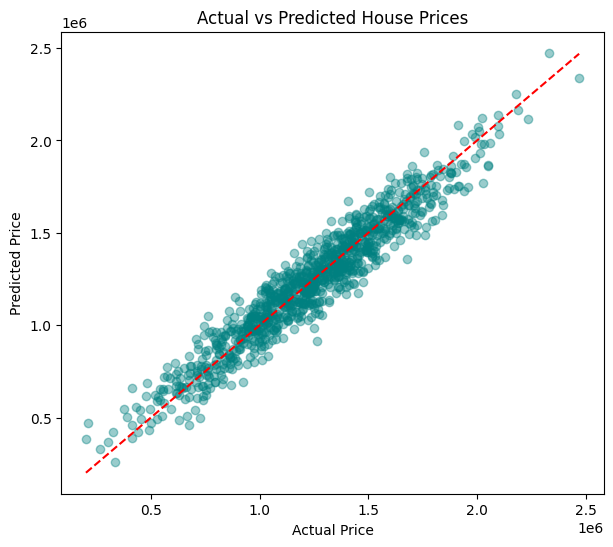

In [16]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

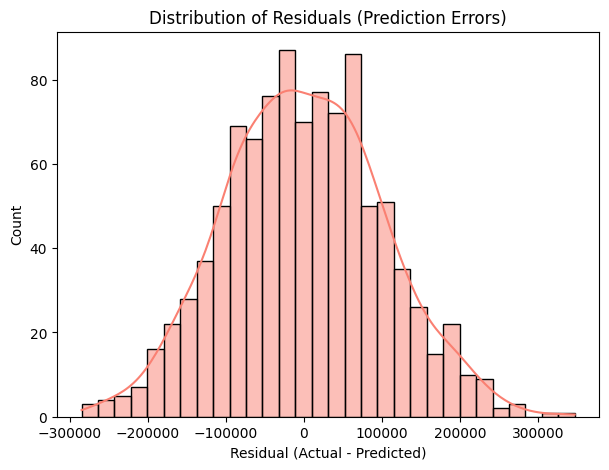

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, bins=30, color="salmon")
plt.title("Distribution of Residuals (Prediction Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

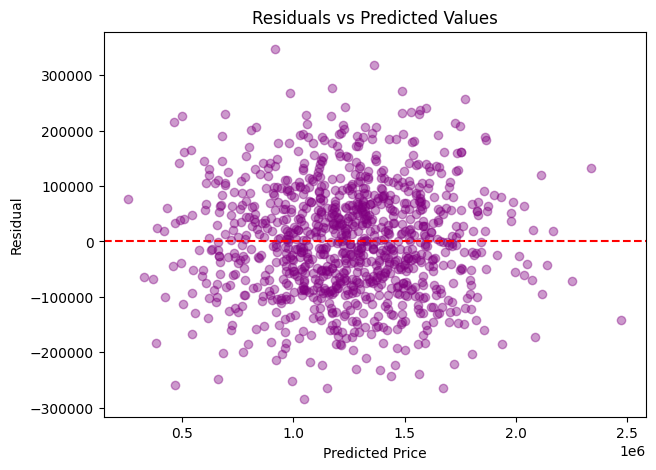

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.4, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

In [19]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)
print("\nIntercept:", model.intercept_)

                        Feature    Coefficient
1           Avg. Area House Age  164666.480722
2     Avg. Area Number of Rooms  119624.012232
3  Avg. Area Number of Bedrooms    2440.377611
0              Avg. Area Income      21.652206
4               Area Population      15.270313

Intercept: -2635072.900933358


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

coef_scaled_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_scaled.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_scaled_df)

                        Feature    Coefficient
0              Avg. Area Income  231741.876652
1           Avg. Area House Age  163580.776566
4               Area Population  152235.900097
2     Avg. Area Number of Rooms  120724.771387
3  Avg. Area Number of Bedrooms    2992.449135


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

coef_scaled_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_scaled.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_scaled_df)

                        Feature    Coefficient
0              Avg. Area Income  231741.876652
1           Avg. Area House Age  163580.776566
4               Area Population  152235.900097
2     Avg. Area Number of Rooms  120724.771387
3  Avg. Area Number of Bedrooms    2992.449135


## Final Summary & Key Insights

### Model Performance
- Linear Regression achieved R² = 0.918 on the test set — explaining ~92% of the
  variance in house prices
- MAE: $80,879 | RMSE: $100,444
- RMSE being higher than MAE indicates a small number of larger prediction errors,
  concentrated mainly in higher-priced homes (visible in the actual-vs-predicted plot)
- Residuals were centered at zero with no clear pattern, indicating the model is
  well-behaved and not systematically biased

### Feature Importance
Using correlation analysis (EDA) and standardized regression coefficients (model),
both methods independently agreed on the same ranking of importance:
1. **Avg. Area Income** — strongest predictor (correlation: 0.64)
2. **Avg. Area House Age**
3. **Area Population**
4. **Avg. Area Number of Rooms**
5. **Avg. Area Number of Bedrooms** — weakest predictor (correlation: 0.17)

### Key Technical Lesson
Initial (unscaled) model coefficients appeared to contradict the EDA findings,
with House Age seeming most important instead of Income. Investigation revealed
this was a scale artifact — features with small numeric ranges require larger
coefficients to achieve equivalent effect on price. After applying StandardScaler,
the coefficients aligned precisely with the correlation-based findings, confirming
Income as the true strongest driver of price.

### Limitations
- Model assumes linear relationships; a more complex model (e.g. Random Forest)
  might capture non-linear patterns and reduce error further, especially at
  higher price ranges
- Dataset represents area-level averages, not individual house-specific features
  (e.g. no data on house condition, exact location, or amenities)

### Conclusion
Area-level income is the dominant factor in predicting house prices in this
dataset, with house age and population also playing meaningful roles. The model
achieves strong, reliable predictive performance (R² = 0.92) and could reasonably
support estimating fair market value at an area level.
